# Contact-insulating loci

## Check for active environment

In [1]:
%%bash
source activate open2c-env
conda info --env

bash: line 1: activate: No such file or directory


# conda environments:
#
base                     /sharehome/gibcus/miniconda3
HiNT-env                 /sharehome/gibcus/miniconda3/envs/HiNT-env
biopython-env            /sharehome/gibcus/miniconda3/envs/biopython-env
eaglec-env               /sharehome/gibcus/miniconda3/envs/eaglec-env
open2c-env            *  /sharehome/gibcus/miniconda3/envs/open2c-env



In [2]:
#%%bash
#pip install git+https://github.com/nvictus/pybbi.git

# Start here

In [1]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import bioframe
import bbi
import os, subprocess

# Import python package for working with cooler files and tools for analysis
import cooler
import cooltools.lib.plotting
from cooltools import insulation

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.1'):
    raise AssertionError("tutorials rely on cooltools version 0.5.1 or higher,"+
                         "please check your cooltools version and update to the latest")

In [2]:
import matplotlib
print(matplotlib.__version__)

3.8.4


In [9]:
import cooltools

# Enter data
conditions = [
    'DE_R1','DE_R2',
    'H1_DE','H1_DEp1','H1_DEp2','H1_DEp3','H1_DEp4','H1_DEp5','H1_DEp6','H1_DEp7','H1_HB',
    'H9_Nup_DE','H9_Nup_DEp1','H9_Nup_DEp2','H9_Nup_DEp3','H9_Nup_DEp4','H9_Nup_DEp5','H9_Nup_DEp6','H9_Nup_DEp7','H9_Nup_HB',
    'HB_R1','HB_R2'
]

example = conditions[0]

# note that there is 1 lane of R1 and R2 libraries to reduce size

long_names = {
    'DE_R1': 'DE-FA-DSG-DdeI-DpnII-20220805-lane01__hg38',
    'DE_R2': 'DE-FA-DSG-DdeI-DpnII-20221212-R2-T1-lane01__hg38',
    'H1_DE': 'DE_HiC3_20240517',
    'H1_DEp1': 'DEp1_HiC3_20240517',
    'H1_DEp2': 'DEp2_HiC3_20240517',
    'H1_DEp3': 'DEp3_HiC3_20240517',
    'H1_DEp4': 'DEp4_HiC3_20240517',
    'H1_DEp5': 'DEp5_HiC3_20240517',
    'H1_DEp6': 'DEp6_HiC3_20240517',
    'H1_DEp7': 'DEp7_HiC3_20240517',
    'H1_HB': 'HB_HiC3_20240517',
    'H9_Nup_DE': 'H9ESCNup155_DE_20241021',
    'H9_Nup_DEp1': 'H9ESCNup155_DEp1_20241021',
    'H9_Nup_DEp2': 'H9ESCNup155_DEp2_20241021',
    'H9_Nup_DEp3': 'H9ESCNup155_DEp3_20241021',
    'H9_Nup_DEp4': 'H9ESCNup155_DEp4_20241021',
    'H9_Nup_DEp5': 'H9ESCNup155_DEp5_20241021',
    'H9_Nup_DEp6': 'H9ESCNup155_DEp6_20241021',
    'H9_Nup_DEp7': 'H9ESCNup155_DEp7_20241021',
    'H9_Nup_HB': 'H9ESCNup155_HB_20241021',
    'HB_R1': 'HB-FA-DSG-DdeI-DpnII-20220805-lane01__hg38',
    'HB_R2': 'HB-FA-DSG-DdeI-DpnII-20221212-R2-T1-lane01__hg38',
}
    
colors = {
    'DE_R1': '#999999',
    'DE_R2': '#cccccc',
    'H1_DE': '#ffffcc',
    'H1_DEp1': '#ffeda0',
    'H1_DEp2': '#fed976',
    'H1_DEp3': '#feb24c',
    'H1_DEp4': '#fd8d3c',
    'H1_DEp5': '#fc4e2a',
    'H1_DEp6': '#e31a1c',
    'H1_DEp7': '#bd0026',
    'H1_HB': '#800026',
    'H9_Nup_DE': '#ffffcc',
    'H9_Nup_DEp1': '#ffeda0',
    'H9_Nup_DEp2': '#fed976',
    'H9_Nup_DEp3': '#feb24c',
    'H9_Nup_DEp4': '#fd8d3c',
    'H9_Nup_DEp5': '#fc4e2a',
    'H9_Nup_DEp6': '#e31a1c',
    'H9_Nup_DEp7': '#bd0026',
    'H9_Nup_HB': '#800026',
    'HB_R1': '#000000',
    'HB_R2': '#333333',
}

binsize = 25_000
windows = [
#         3*binsize, 
        5*binsize, 
#         10*binsize, 
#         25*binsize
]



dataDir = f'/abyss/gibcus/gibcus_mnt_genomics/4DN/coolers/'
outDataDir = f'/abyss/gibcus/data/UM1/insulation'
figureDir = f'/sharehome/xiangruhuo/4DN_scripts/plot'

cooler_path = {}
for cond in conditions:
    cooler_path[cond] = f'{dataDir}/{long_names[cond]}.hg38.mapq_30.1000.mcool::resolutions/{binsize}'

clrs = {
    cond: cooler.Cooler(cooler_path[cond]) for cond in conditions
}

# Calculating genome-wide contact insulation

In [4]:
# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)

# Select only chromosomes that are present in the cooler. 
hg38_arms = hg38_arms.set_index("chrom").loc[clrs[example].chromnames].reset_index()

insulation_table = {}

for cond in conditions:
    for window in windows:
        print("calculating... " +cond)
        os.chdir(f'{outDataDir}')
        if not os.path.isfile(f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.insul_{str(window)}.tsv'):
            insulation_table[cond] = insulation(clrs[cond], 
                                                windows,
                                                threshold='Li',
                                                verbose=False,
                                               )
            print("number of boundaries: " +str(len(insulation_table[cond])))
            insulation_table[cond][['chrom','start','end','log2_insulation_score_'+str(window),'boundary_strength_'+str(window)]].to_csv(f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.insul_{str(window)}.bedgraph', sep='\t', na_rep = 'nan', header = True)

            insulation_table[cond].to_csv(f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.insul_{str(window)}.tsv', sep='\t')
            bioframe.to_bigwig(insulation_table[cond], hg38_chromsizes, 
                               f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.insul_{str(window)}.bw', 
                               f'log2_insulation_score_{window}')
            bioframe.to_bigwig(insulation_table[cond], hg38_chromsizes, 
                               f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.insul_pp_{str(window)}.bw', 
                               f'boundary_strength_{window}')

        insulation_table[cond] = pd.read_csv(f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.insul_{str(window)}.tsv',sep='\t',index_col=0)


calculating... DE_R1
calculating... DE_R2
calculating... H1_DE
calculating... H1_DEp1
calculating... H1_DEp2
calculating... H1_DEp3
calculating... H1_DEp4
calculating... H1_DEp5
calculating... H1_DEp6
calculating... H1_DEp7
calculating... H1_HB
calculating... H9_Nup_DE
calculating... H9_Nup_DEp1
calculating... H9_Nup_DEp2
calculating... H9_Nup_DEp3
calculating... H9_Nup_DEp4
calculating... H9_Nup_DEp5
calculating... H9_Nup_DEp6
calculating... H9_Nup_DEp7
calculating... H9_Nup_HB
calculating... HB_R1
calculating... HB_R2


# Boundary calling

In [5]:
# Functions to help with plotting
def pcolormesh_45deg(ax, matrix_c, start=0, resolution=1, *args, **kwargs):
    start_pos_vector = [start+resolution*i for i in range(len(matrix_c)+1)]
    import itertools
    n = matrix_c.shape[0]
    t = np.array([[1, 0.5], [-1, 0.5]])
    matrix_a = np.dot(np.array([(i[1], i[0])
                                for i in itertools.product(start_pos_vector[::-1],
                                                           start_pos_vector)]), t)
    x = matrix_a[:, 1].reshape(n + 1, n + 1)
    y = matrix_a[:, 0].reshape(n + 1, n + 1)
    im = ax.pcolormesh(x, y, np.flipud(matrix_c), *args, **kwargs)
    im.set_rasterized(True)
    return im

from matplotlib.ticker import EngFormatter
bp_formatter = EngFormatter('b')
def format_ticks(ax, x=True, y=True, rotate=True):
    if y:
        ax.yaxis.set_major_formatter(bp_formatter)
    if x:
        ax.xaxis.set_major_formatter(bp_formatter)
        ax.xaxis.tick_bottom()
    if rotate:
        ax.tick_params(axis='x',rotation=45)

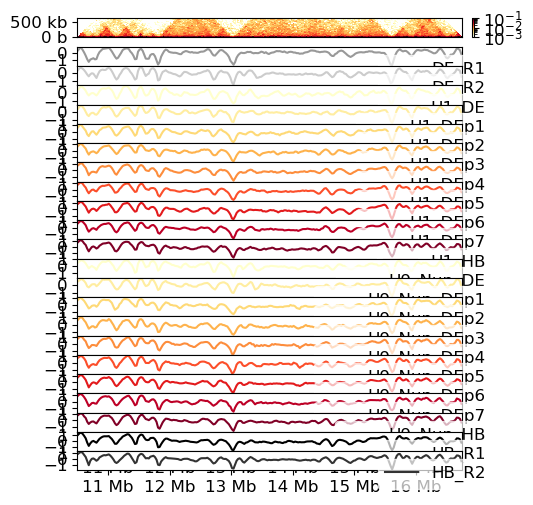

In [11]:
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import bioframe
plt.rcParams['font.size'] = 12

start = 10_500_000
end = start+ 50*windows[0]
region = ('chr2', start, end)
norm = LogNorm(vmax=0.1, vmin=0.001)
data = clrs[example].matrix(balance=True).fetch(region)
f, ax = plt.subplots(figsize=(18, 6))
im = pcolormesh_45deg(ax, data, start=region[1], resolution=binsize, norm=norm, cmap='fall')
ax.set_aspect(0.5)
ax.set_ylim(0, 5*windows[0])
format_ticks(ax, rotate=False)
ax.xaxis.set_visible(False)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="0.4%", pad=0.1, aspect=6)
plt.colorbar(im, cax=cax)

insul_region = {}
for cond in conditions:
    insul_region[cond] = bioframe.select(insulation_table[cond], region)

    ins_ax = divider.append_axes("bottom", size="50%", pad=0., sharex=ax)
#     ins_ax.set_prop_cycle(plt.cycler("color", plt.cm.plasma(np.linspace(0,1,5))))
    ins_ax.plot(insul_region[cond][['start', 'end']].mean(axis=1).values,
            insul_region[cond][f'log2_insulation_score_{window}'].values,
            label=f'{cond}', color=colors[cond])
    ins_ax.legend( bbox_to_anchor=(1.1,1), loc=1, ncol=1, shadow=False, fontsize='medium', frameon=True, facecolor='#FFFFFF', edgecolor='#FFFFFF', framealpha=0.7);

format_ticks(ins_ax, y=False, rotate=False)
ax.set_xlim(region[1], region[2])

from matplotlib.backends.backend_pdf import PdfPages
pp = PdfPages(f'{figureDir}/insulation.pdf')
plt.savefig(pp, format='pdf')

In [7]:
boundaries = {}

for cond in conditions:
    is_boundary = np.any([
            ~insulation_table[cond][f'boundary_strength_{window}'].isnull()
            for window in windows],
        axis=0)

    boundaries[cond] = insulation_table[cond][is_boundary]
    print(len(boundaries[cond]))

# boundaries[example].head()

14510
15035
16183
16257
15752
15657
15073
15182
15358
15319
14899
14999
15784
15940
15312
15026
14877
14622
15149
14931
14571
14411


# Pileup at boundaries

In [12]:
peaks = {}
pscore = {}
inscore = {}
cols = {}

for window in windows:    
    pscore[window] = f'boundary_strength_{str(window)}'
    inscore[window] = f'log2_insulation_score_{str(window)}'
                                  
    cols[window] = ['chrom', 'start', 'end', inscore[window], pscore[window]]
                                      
    for cond in conditions:
        peaks[cond] = (boundaries[cond][cols[window]])
        peaks[cond].to_csv(f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.peaks_{window}.tsv', sep='\t', index = False)
        bioframe.to_bigwig(peaks[cond], hg38_chromsizes, 
                                       f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.peaks_{str(window)}.bw', 
                                       f'log2_insulation_score_{window}')

print(len(peaks[example]))
peaks[example].head()

14510


,chrom,start,end,log2_insulation_score_125000,boundary_strength_125000
43,chr1,1075000,1100000,-0.186108,0.263044
53,chr1,1325000,1350000,-0.713691,1.221126
63,chr1,1575000,1600000,-0.383035,0.475673
76,chr1,1900000,1925000,-0.874624,2.513218
83,chr1,2075000,2100000,-0.646937,0.935421


In [13]:
AsyncBounds = {}
for cond in conditions:
    for window in windows:
        AsyncBounds [cond] = pd.read_csv(f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.peaks_{window}.tsv', sep = '\t')

In [14]:
#plot insulation score at TAD boundaries compared to actual data
stacks = {}
for i, cond in enumerate(conditions):
    for window in windows:
        mids = (AsyncBounds[cond]['start'] + AsyncBounds[cond]['end']) // 2
        flank = 10*binsize
        nbins = flank*2 // binsize
        bwfile = f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.insul_{str(window)}.bw' #insulation
#         bwfile = f'{outDataDir}/{long_names[cond]}.{binsize//1000}kb.peaks_{str(window)}.bw' #peaks
        stacks[cond] = bbi.stackup(bwfile, AsyncBounds[cond]['chrom'], mids - flank, mids + flank, bins=nbins)


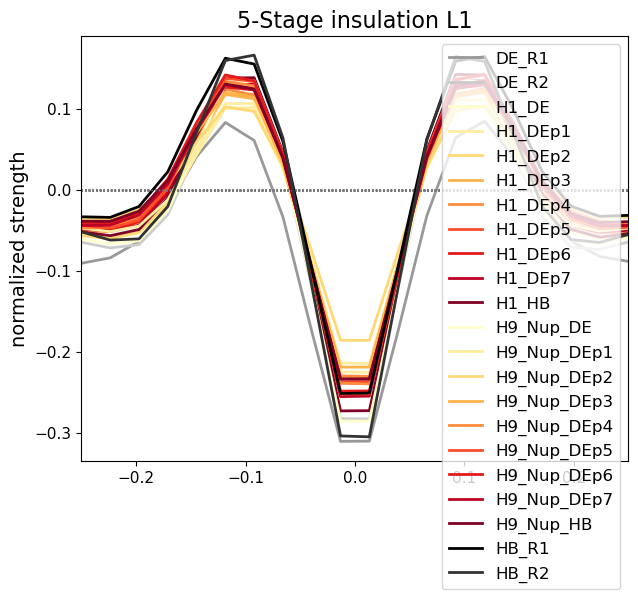

In [15]:
# Insulation
flank = 10*binsize
binkb = binsize
nbins = flank*2 // binsize
x = np.linspace(-flank/1e6, flank/1e6, nbins)

gsIns = plt.GridSpec(nrows=5, ncols=3)
plt.figure(figsize=(24, 32))

plt.subplot(gsIns[0])
for cond in conditions:
    plt.axhline(0, c='#777777', lw=1, ls=':')
    plt.plot(x, np.nanmean(stacks[cond], axis=0), lw=2, ls='-', label = cond, color=colors[cond])
    plt.xlim(-flank/1e6, flank/1e6)
#     plt.ylim(-.2, .1)
    plt.ylabel('normalized strength',size=14)    
    plt.legend()
    plt.yticks(fontsize=11)    
    plt.xticks(fontsize=11)    
    plt.xlabel('',size=14)
    plt.title('5-Stage insulation L1', size=16)

In [16]:
# Insulation definitions
flank = 250000
nbins = flank*2 // binsize
x = np.linspace(-flank/1000, flank/1000, nbins+1)
window_bp = 5*binsize

bstren = {}
for window in windows:
    bstren[window] = f'boundary_strength_{window}'

    def pile_up(df):
        start = df[(df[bstren[window]] >= 0.001)].index -10 # Note the 0.001 is arbitrary cutoff to call boundaries (>0 for log)
        end  = df[(df[bstren[window]] >= 0.001)].index +11 
        return (np.nanmean(np.array(list(map(lambda x: df[inscore[window]].values[x[0]:x[1]],
                                  zip(start,end)))), axis=0))

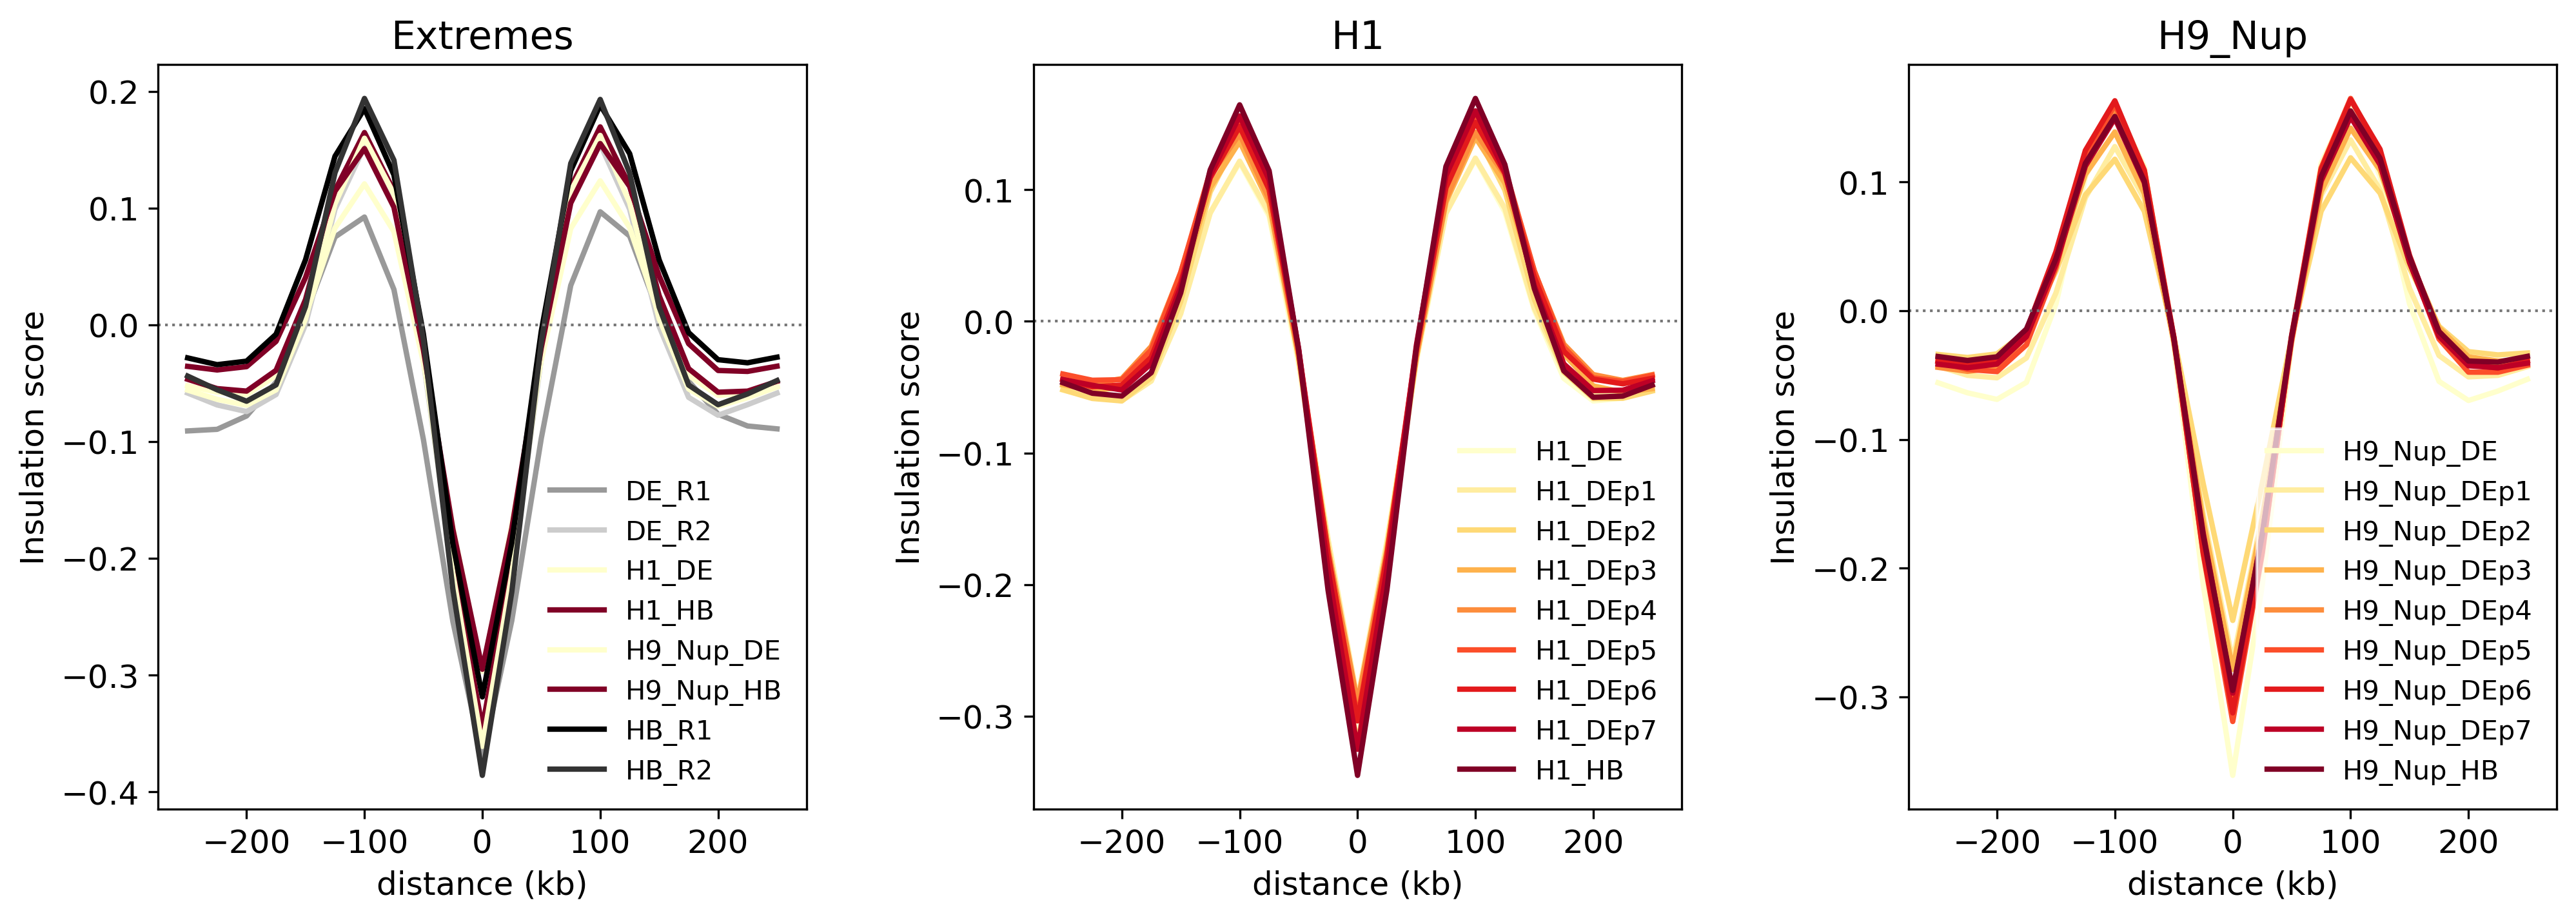

Saved PDF to: /sharehome/xiangruhuo/4DN_scripts/plot/insulation_pileup_three_groups.pdf


In [18]:
extremes = ['DE_R1','DE_R2','H1_DE','H1_HB','H9_Nup_DE','H9_Nup_HB','HB_R1','HB_R2']
H1_only = ['H1_DE','H1_DEp1','H1_DEp2','H1_DEp3','H1_DEp4','H1_DEp5','H1_DEp6','H1_DEp7','H1_HB']
H9_Nup_only = ['H9_Nup_DE','H9_Nup_DEp1','H9_Nup_DEp2','H9_Nup_DEp3','H9_Nup_DEp4','H9_Nup_DEp5','H9_Nup_DEp6','H9_Nup_DEp7','H9_Nup_HB']

save_dir = figureDir   # or "/home/xiangru.huo-umw/scHiC/scripts/plot"
os.makedirs(save_dir, exist_ok=True)

save_path = f"{save_dir}/insulation_pileup_three_groups.pdf"

fig = plt.figure(figsize=(16, 5), dpi=300)
gs = plt.GridSpec(nrows=1, ncols=3, figure=fig, wspace=0.35)

def Plotz(ax, title):
    ax.axhline(0, c="#777777", lw=1, ls=":")
    ax.set_xlabel("distance (kb)")
    ax.set_ylabel("Insulation score")
    ax.set_title(title)
    ax.legend(
        loc="lower right",
        ncol=1,
        shadow=False,
        fontsize="small",
        frameon=True,
        facecolor="#FFFFFF",
        edgecolor="#FFFFFF",
        framealpha=0.7
    )

# -------------------------
# Panel 1: extremes
# -------------------------
ax = fig.add_subplot(gs[0])

for cond in extremes:
    for window in windows:
        ax.plot(
            x,
            pile_up(insulation_table[cond]),
            lw=2,
            ls="-",
            label=cond,
            color=colors[cond]
        )

Plotz(ax, "Extremes")


# -------------------------
# Panel 2: H1 only
# -------------------------
ax = fig.add_subplot(gs[1])

for cond in H1_only:
    for window in windows:
        ax.plot(
            x,
            pile_up(insulation_table[cond]),
            lw=2,
            ls="-",
            label=cond,
            color=colors[cond]
        )

Plotz(ax, "H1")


# -------------------------
# Panel 3: H9 Nup only
# -------------------------
ax = fig.add_subplot(gs[2])

for cond in H9_Nup_only:
    for window in windows:
        ax.plot(
            x,
            pile_up(insulation_table[cond]),
            lw=2,
            ls="-",
            label=cond,
            color=colors[cond]
        )

Plotz(ax, "H9_Nup")


# -------------------------
# Save
# -------------------------
fig.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)

print(f"Saved PDF to: {save_path}")

In [38]:
#trying to get difference between min/max for insulation to plot one value over time
insuls = {}
diff_insul = {}

#Two options for determing insulation strength: (1) by minumum, (2) by difference between min and max

for cond in conditions:
    insuls[cond] = (np.nanmean(stacks[cond], axis=0))
#     diff_insul[cond] = -1*min(insuls[cond])                    #(1)
    diff_insul[cond] = max(insuls[cond])-min(insuls[cond])       #(2)
insuls[example]

array([-0.09085384, -0.08420164, -0.06385367, -0.02103178,  0.04080163,
        0.08293538,  0.06074341, -0.03375018, -0.17487653, -0.31072403,
       -0.31039639, -0.17424016, -0.0318954 ,  0.0643558 ,  0.08444401,
        0.04094285, -0.02061062, -0.06305685, -0.0824841 , -0.08861307])

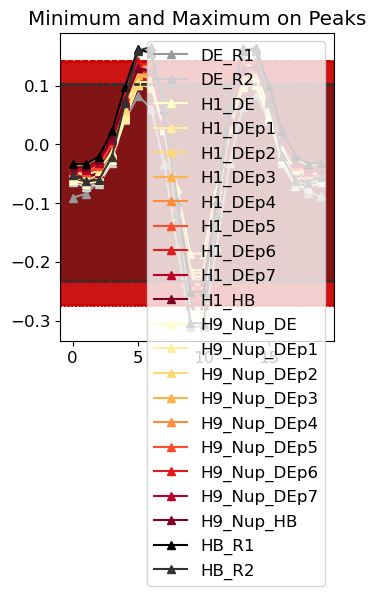

In [21]:
gs = plt.GridSpec(nrows=1, ncols=3)
plt.figure(figsize=(12, 4))

plt.subplot(gs[0])
for cond in conditions:   
    plt.plot(insuls[cond], 'r^', ls='-', label = cond, color=colors[cond])
#     plt.xlim(-flank/1e6, flank/1e6)
#     plt.ylim(-.2, .1)
    plt.axhline(max(insuls['H1_HB']), c='#cc0000', ls='--', lw=1)
    plt.axhline(max(insuls['H1_DE']), c='#333333', ls='--', lw=1)
    plt.axhline(min(insuls['H1_HB']), c='#cc0000', ls=':', lw=1)
    plt.axhline(min(insuls['H1_DE']), c='#333333', ls=':', lw=1)
    plt.axhspan(min(insuls['H1_DE']), max(insuls['H1_DE']), alpha=0.1, color='#333333')
    plt.axhspan(min(insuls['H1_HB']), max(insuls['H1_HB']), alpha=0.1, color='#cc0000')
    plt.legend()
    plt.title('Minimum and Maximum on Peaks')


In [22]:
diff_insul

{'DE_R1': 0.39516803335762696,
 'DE_R2': 0.41276776773603274,
 'H1_DE': 0.33532291771478984,
 'H1_DEp1': 0.3286266083474873,
 'H1_DEp2': 0.37316713379992617,
 'H1_DEp3': 0.3540649365183497,
 'H1_DEp4': 0.3551420888357088,
 'H1_DEp5': 0.3716991573075422,
 'H1_DEp6': 0.36865277951048697,
 'H1_DEp7': 0.38996020506118345,
 'H1_HB': 0.4153642386218773,
 'H9_Nup_DE': 0.42294701657143674,
 'H9_Nup_DEp1': 0.32585777708202923,
 'H9_Nup_DEp2': 0.2890947216691714,
 'H9_Nup_DEp3': 0.34205313869060816,
 'H9_Nup_DEp4': 0.37354196690866426,
 'H9_Nup_DEp5': 0.3938303757773106,
 'H9_Nup_DEp6': 0.3909360074099233,
 'H9_Nup_DEp7': 0.3638604704978593,
 'H9_Nup_HB': 0.3671496495455713,
 'HB_R1': 0.41594107750947573,
 'HB_R2': 0.4710782690150622}